# Task 6: Support Vector Machine (SVM)

## Objective
- Load and explore the Iris dataset
- Preprocess the data
- Train an SVM classifier
- Generate predictions
- Evaluate model performance
- Visualize the confusion matrix

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#Load Dataset
df = pd.read_csv("../datasets/iris.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
#Display Dataset
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
#Dataset Overview
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
#Ckeck Missing Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [7]:
#Encode Target Column
label_encoder = LabelEncoder()

df["species"] = label_encoder.fit_transform(df["species"])

print("Species column encoded successfully!")

df.head()

Species column encoded successfully!


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
#Separate Features and Target

X = df.drop("species", axis=1)
y = df["species"] 
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [9]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (120, 4)
X_test: (30, 4)


In [10]:
#Train SVM Model
model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [11]:

#Predictions

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 2 1 1 0 1 0 0 2 1]


In [12]:
#Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9666666666666667
Accuracy (%): 96.66666666666667


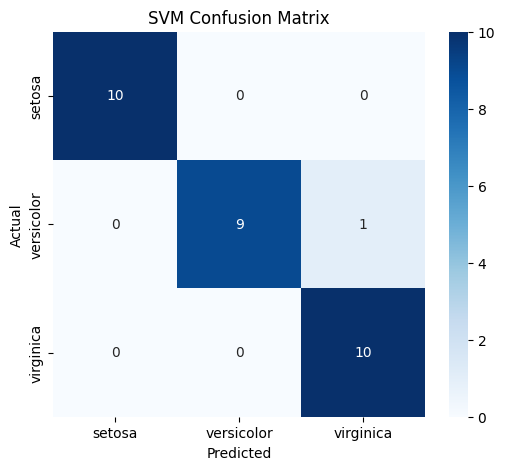

In [13]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [14]:
#Classification Report

print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [15]:
#Support Vectors Information

print("Number of Support Vectors for each class:")
print(model.n_support_)

print("\nTotal Support Vectors:")
print(model.support_vectors_.shape[0])

Number of Support Vectors for each class:
[ 5 23 21]

Total Support Vectors:
49


# Conclusion

The Support Vector Machine (SVM) classifier was successfully implemented using the Iris dataset.

### Work Completed
- Loaded and explored the Iris dataset.
- Checked for missing values.
- Encoded the target variable.
- Prepared features and target variable.
- Split the dataset into training and testing sets.
- Trained an SVM classifier.
- Generated predictions.
- Evaluated the model using Accuracy, Confusion Matrix, and Classification Report.
- Analyzed the number of support vectors used by the classifier.

The SVM model achieved excellent classification performance and demonstrated its effectiveness in accurately classifying Iris flower species.